# Reading and Interpolating TPXO Tidal Harmonics

This tutorial demonstrates how to read TPXO tidal harmonics data and interpolate it onto a target
grid using PyFVCOM2. This is useful for:

- Generating tidal boundary forcing for FVCOM from TPXO global tidal models
- Inspecting tidal constituent amplitudes and phases on your model domain
- Comparing TPXO tidal predictions with observations or other models

## Overview

TPXO provides global tidal harmonic data on a regular longitude/latitude grid. The data is stored
as amplitude and phase (or real/imaginary components) for each tidal constituent. To use this data
with FVCOM, we need to interpolate it onto the FVCOM grid or open boundary nodes.

The key steps are:
1. Load TPXO harmonics using `TPXOHarmonicsReader`
2. Define target interpolation coordinates
3. Use `TPXOInterpolator` to interpolate harmonics onto the target positions
4. Visualise the interpolated amplitude and phase fields

### A note on phase interpolation

Directly interpolating tidal phase is problematic because of the discontinuity at 360°/0°.
`TPXOInterpolator` handles this by decomposing each constituent's amplitude and phase into two
cartesian components using `pol2cart`, interpolating these smooth fields independently, and then
converting back to amplitude and phase with `cart2pol`.

## Prerequisites

Before running this tutorial, ensure you have:
- TPXO harmonics files in NetCDF format (here we use TPXO9.v1)
- The PyFVCOM2 package installed
- Cartopy installed (for map projections in the plots)

## Step 1: Import Required Libraries

In [1]:
from collections import namedtuple
import pathlib
import numpy as np
from glob import glob
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from pyfvcom2.fvcom_reader import FVCOMReader
from pyfvcom2.interpolation import InterpolationCoordinates, TPXOInterpolator
from pyfvcom2.tide_reader import TPXOHarmonicsReader, get_tpxo_harmonics_names
from pyfvcom2.plotting import create_figure

## Step 2: Define the Target Grid

We reuse the same FVCOM domain as in the `interpolate_fvcom_data` tutorial to define the
target grid. The grid limits are taken from the FVCOM mesh, and we create a regular
longitude/latitude grid spanning the domain.

In [2]:
# Load FVCOM grid to get domain limits
fvcom_data_dir = pathlib.Path('/users/modellers/jcl/data/pylag_doc')
fvcom_file_stem = 'fvcom_tamar_estuary_000'
fvcom_file_list = sorted(glob(str(fvcom_data_dir / f'{fvcom_file_stem}*.nc')))
fvcom_reader = FVCOMReader(fvcom_file_list)

# Named tuple for the grid limits
GridLims = namedtuple('GridLims', ('lon_min', 'lon_max', 'lat_min', 'lat_max'))


def get_lons_lats(grid_lims, points_per_degree):
    """Generate 1D lon and lat arrays for a regular grid."""
    n_lon = int((grid_lims.lon_max - grid_lims.lon_min) * points_per_degree)
    n_lat = int((grid_lims.lat_max - grid_lims.lat_min) * points_per_degree)
    lon = np.linspace(grid_lims.lon_min, grid_lims.lon_max, n_lon, dtype=float)
    lat = np.linspace(grid_lims.lat_min, grid_lims.lat_max, n_lat, dtype=float)
    return lon, lat


# Get grid limits from the FVCOM mesh
grid_lims = GridLims(
    fvcom_reader.grid.lon.min(),
    fvcom_reader.grid.lon.max(),
    fvcom_reader.grid.lat.min(),
    fvcom_reader.grid.lat.max(),
)

# Grid resolution
points_per_degree = 72

# Generate the regular grid
lon, lat = get_lons_lats(grid_lims, points_per_degree)
lon_2D, lat_2D = np.meshgrid(lon, lat, indexing='ij')
lon_flat = lon_2D.flatten()
lat_flat = lat_2D.flatten()

print(f'Domain: {grid_lims}')
print(f'Number of horizontal interpolation points: {lon_flat.size}')

Accessing FVCOM metadata from: /users/modellers/jcl/data/pylag_doc/fvcom_tamar_estuary_0001.nc
Domain: GridLims(lon_min=np.float32(-4.8078494), lon_max=np.float32(-3.804414), lat_min=np.float32(49.72116), lat_max=np.float32(50.519005))
Number of horizontal interpolation points: 4104


## Step 3: Create Interpolation Coordinates

Bundle the target positions into an `InterpolationCoordinates` object. For tidal harmonics
we only need horizontal coordinates — there is no time or depth dimension.

In [3]:
interp_coords = InterpolationCoordinates(
    dates=None,
    x3=None,
    x1=lon_flat,
    x2=lat_flat,
    horizontal_coordinate_system='geographic',
    vertical_coordinate_system='z',
)

## Step 4: Read and Interpolate Elevation Harmonics (zeta)

We use `TPXOHarmonicsReader` to load the tidal elevation harmonics from the TPXO9 file,
then use `TPXOInterpolator` to interpolate them onto our target grid.

The `get_tpxo_harmonics_names` helper returns the correct variable names for the TPXO
amplitude/phase format. For zeta, these are `ha` (amplitude) and `hp` (phase).

The TPXO file uses 0–360° longitudes, while the FVCOM domain uses negative longitudes
(~-4°). `TPXOInterpolator` detects and corrects this mismatch automatically.

In [4]:
# Path to the TPXO9 elevation harmonics file
tpxo_h_file = pathlib.Path('/data/sthenno1/backup/jcl/data/TPXO/DATA/h_tpxo9.v1.nc')

# Constituent list
constituents = ['M2', 'S2', 'N2', 'K1', 'O1']

# Read harmonics
h_reader = TPXOHarmonicsReader(str(tpxo_h_file))
h_var_names = get_tpxo_harmonics_names('zeta')
h_harmonics = h_reader.read_harmonics(constituents, h_var_names)

print(f'Loaded constituents: {h_harmonics.constituents}')
print(f'Amplitude shape: {np.asarray(h_harmonics.amplitudes).shape}')

# Interpolate onto target grid
h_interpolator = TPXOInterpolator(h_harmonics)
h_result = h_interpolator.interpolate(interp_coords)

print(f'Interpolated amplitude shape: {h_result.amplitudes.shape}')  # (n_points, n_constituents)

Loaded constituents: ['M2', 'S2', 'N2', 'K1', 'O1']
Amplitude shape: (5, 2160, 1081)
Interpolated amplitude shape: (4104, 5)


## Step 5a: Plot Original (Uninterpolated) Elevation Data

Before looking at the interpolated result, let’s visualise the raw TPXO elevation
harmonics over the same domain. The TPXO grid uses 0–360° longitudes, so we
shift values > 180° to negative before subsetting to the domain extent.

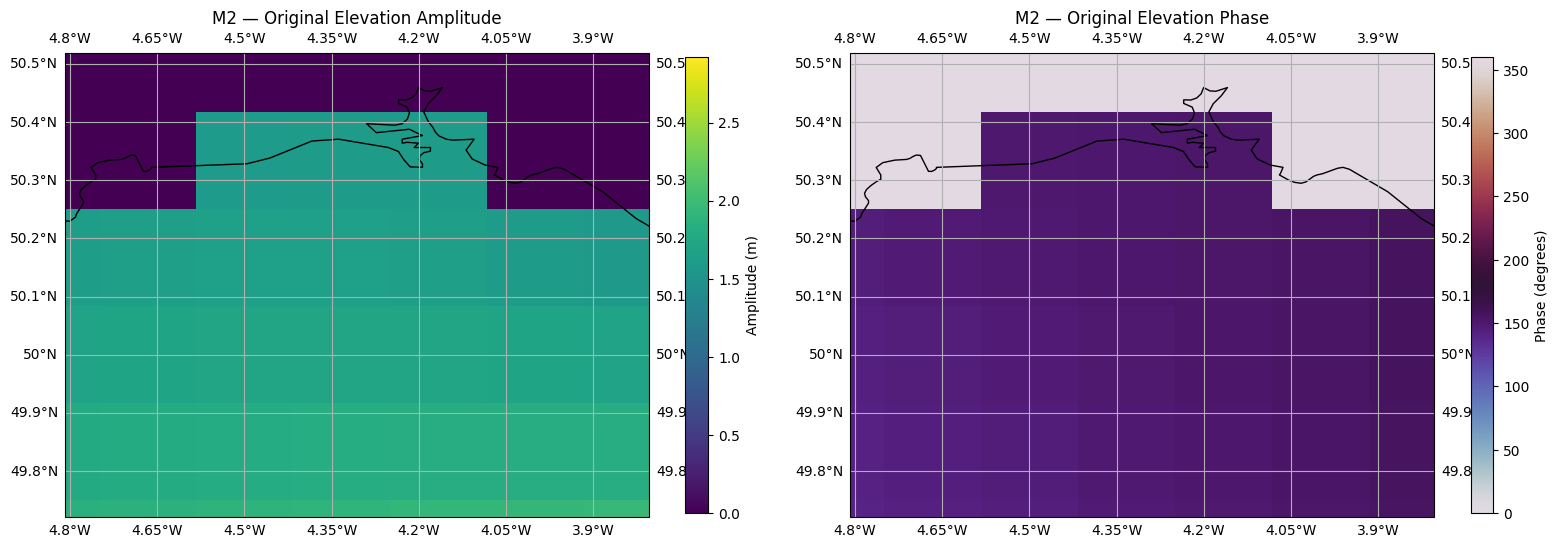

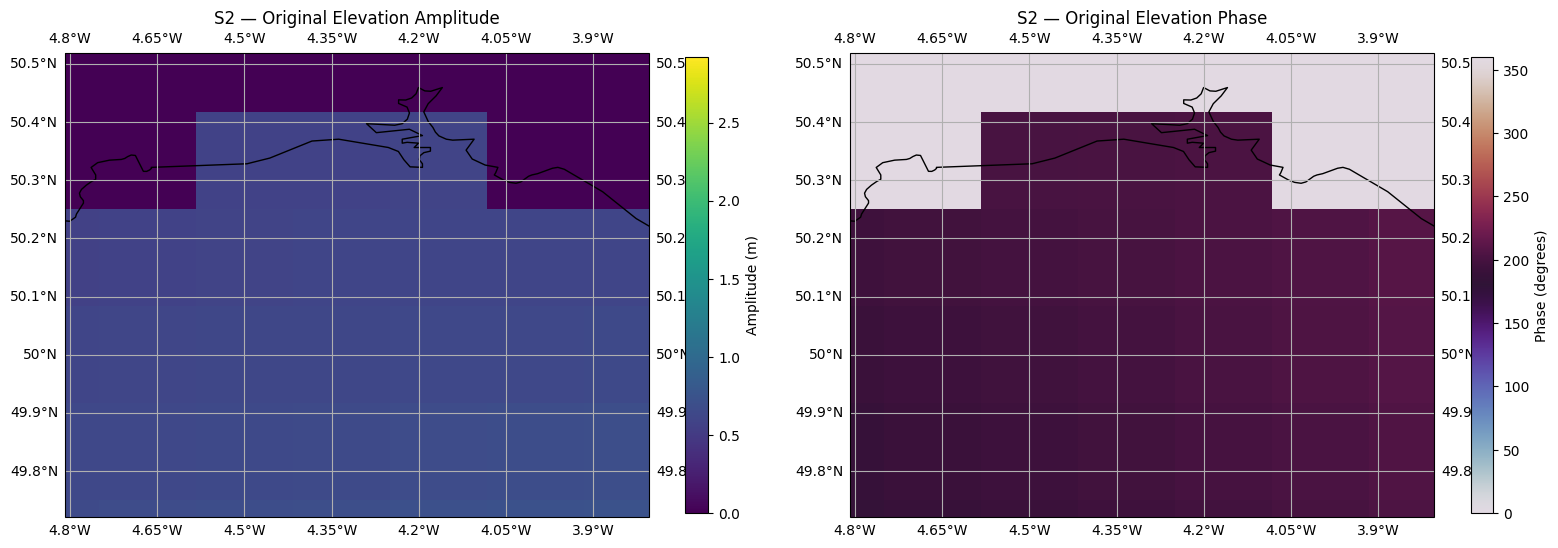

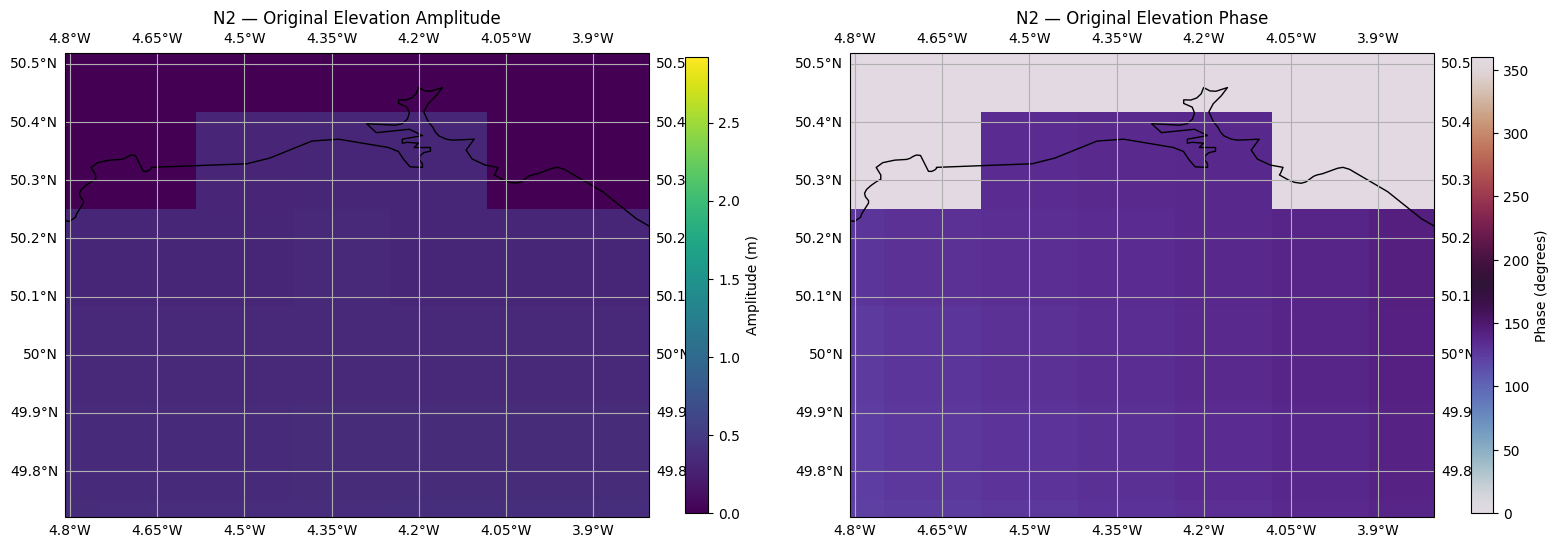

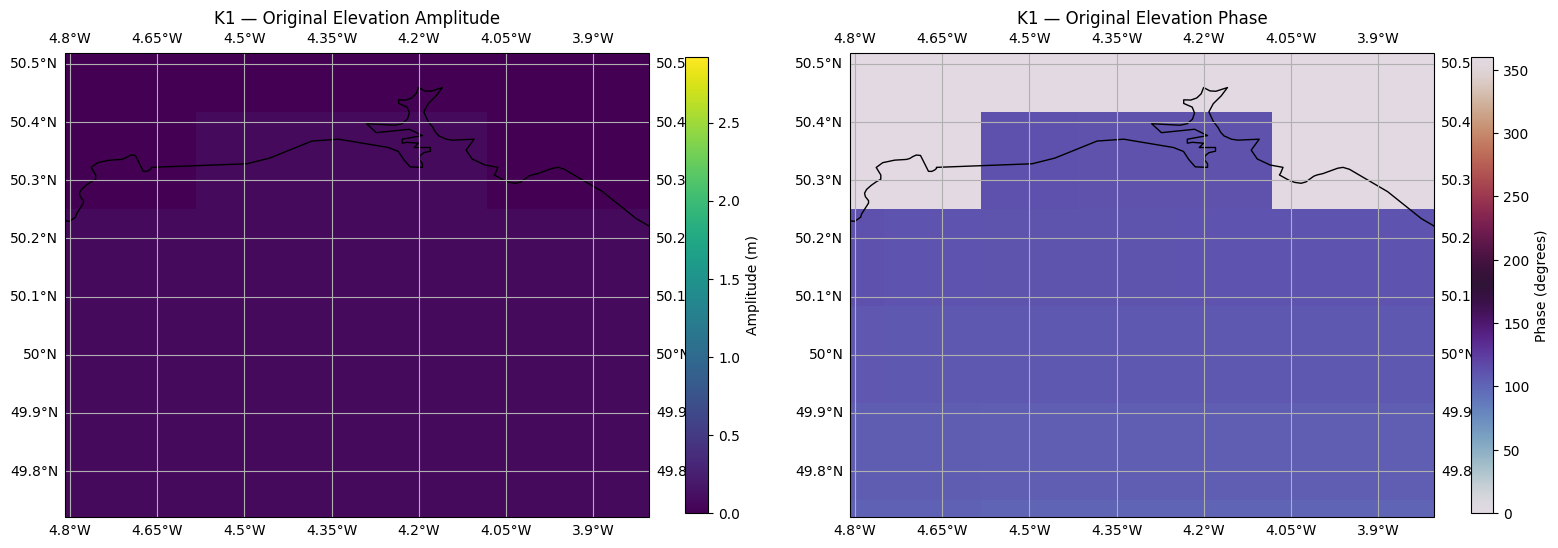

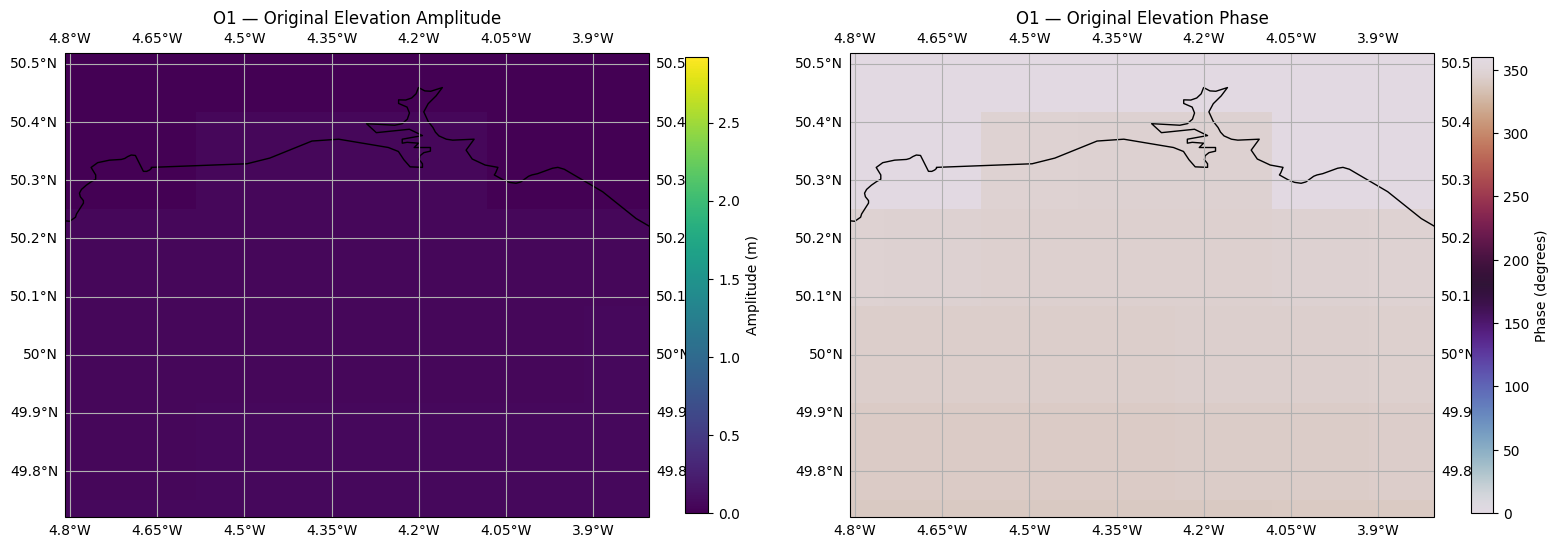

In [5]:
extent = [grid_lims.lon_min, grid_lims.lon_max, grid_lims.lat_min, grid_lims.lat_max]

# Prepare the raw TPXO elevation grid for plotting
h_lon_raw = np.asarray(h_harmonics.longitude)
h_lat_raw = np.asarray(h_harmonics.latitude)

# Get 1D coordinate vectors from the 2D arrays
h_lon_1d = np.unique(h_lon_raw)
h_lat_1d = np.unique(h_lat_raw)

# Shift longitudes from 0-360 to -180..180
h_lon_1d = np.where(h_lon_1d > 180, h_lon_1d - 360, h_lon_1d)
sort_idx = np.argsort(h_lon_1d)
h_lon_1d = h_lon_1d[sort_idx]

# Subset to the domain extent (with a small margin)
margin = 0.5
lon_mask = (h_lon_1d >= grid_lims.lon_min - margin) & (h_lon_1d <= grid_lims.lon_max + margin)
lat_mask = (h_lat_1d >= grid_lims.lat_min - margin) & (h_lat_1d <= grid_lims.lat_max + margin)

h_lon_sub = h_lon_1d[lon_mask]
h_lat_sub = h_lat_1d[lat_mask]
h_lon_sub_2d, h_lat_sub_2d = np.meshgrid(h_lon_sub, h_lat_sub, indexing='ij')

h_amp_raw = np.asarray(h_harmonics.amplitudes)  # (nc, nx, ny)
h_phase_raw = np.asarray(h_harmonics.phases)

# Reorder longitudes, then subset
h_amp_raw = h_amp_raw[:, sort_idx, :]
h_phase_raw = h_phase_raw[:, sort_idx, :]
h_amp_sub = h_amp_raw[:, lon_mask, :][:, :, lat_mask]
h_phase_sub = h_phase_raw[:, lon_mask, :][:, :, lat_mask]

# Compute shared colorbar limits across all constituents for original and interpolated
h_amp_vmin = min(np.nanmin(h_amp_sub), np.nanmin(h_result.amplitudes))
h_amp_vmax = max(np.nanmax(h_amp_sub), np.nanmax(h_result.amplitudes))

for c_idx, constituent in enumerate(h_harmonics.constituents):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6),
                             subplot_kw={'projection': ccrs.PlateCarree()})

    # Amplitude
    pc = axes[0].pcolormesh(h_lon_sub_2d, h_lat_sub_2d, h_amp_sub[c_idx],
                            cmap='viridis', transform=ccrs.PlateCarree(), shading='auto',
                            vmin=h_amp_vmin, vmax=h_amp_vmax)
    axes[0].coastlines(resolution='10m')
    axes[0].add_feature(cfeature.LAND, facecolor='lightgrey')
    axes[0].gridlines(draw_labels=True)
    axes[0].set_extent(extent, crs=ccrs.PlateCarree())
    cbar = plt.colorbar(pc, ax=axes[0], shrink=0.8)
    cbar.set_label('Amplitude (m)')
    axes[0].set_title(f'{constituent} — Original Elevation Amplitude')

    # Phase
    pc = axes[1].pcolormesh(h_lon_sub_2d, h_lat_sub_2d, h_phase_sub[c_idx],
                            cmap='twilight', transform=ccrs.PlateCarree(), shading='auto',
                            vmin=0, vmax=360)
    axes[1].coastlines(resolution='10m')
    axes[1].add_feature(cfeature.LAND, facecolor='lightgrey')
    axes[1].gridlines(draw_labels=True)
    axes[1].set_extent(extent, crs=ccrs.PlateCarree())
    cbar = plt.colorbar(pc, ax=axes[1], shrink=0.8)
    cbar.set_label('Phase (degrees)')
    axes[1].set_title(f'{constituent} — Original Elevation Phase')

    plt.tight_layout()
    plt.show()

## Step 5b: Plot Interpolated Elevation Amplitude and Phase

Plot the interpolated tidal amplitude and phase for each constituent.

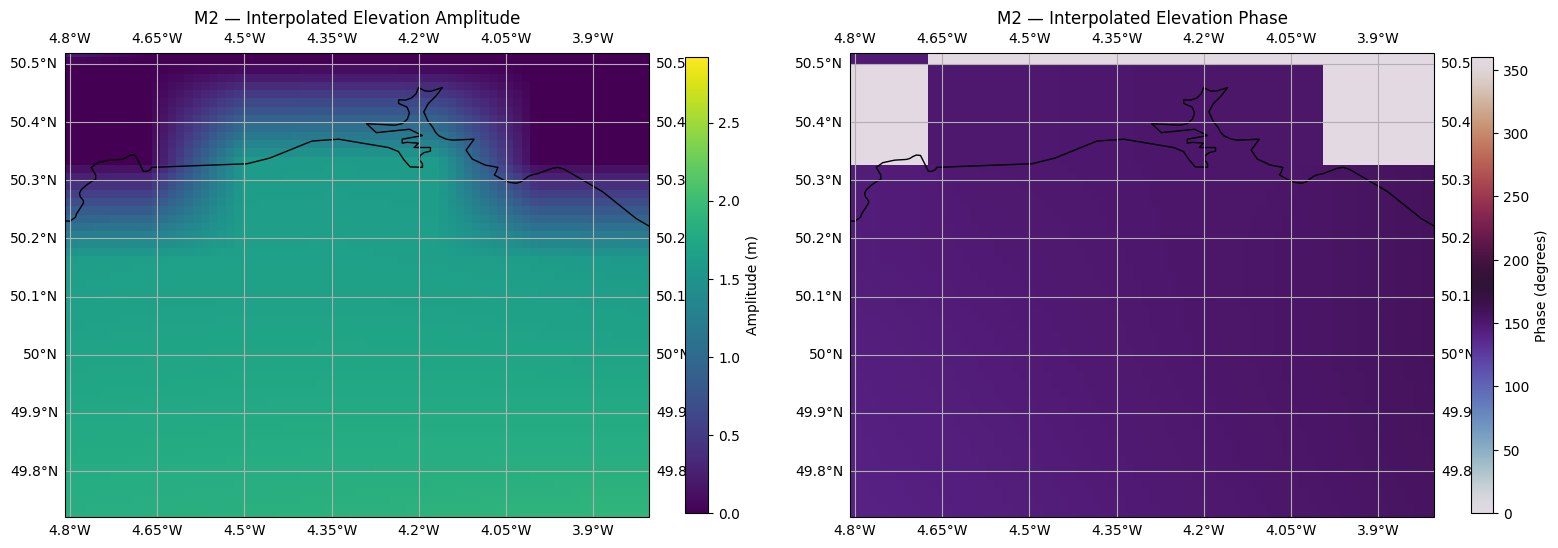

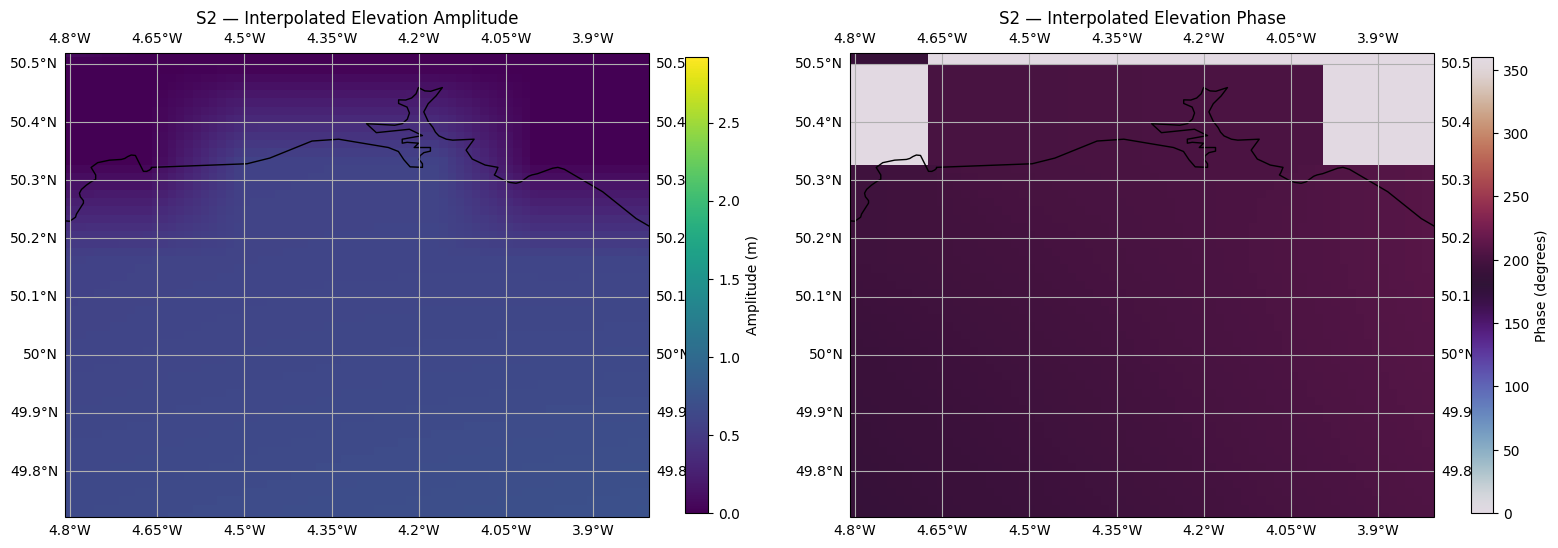

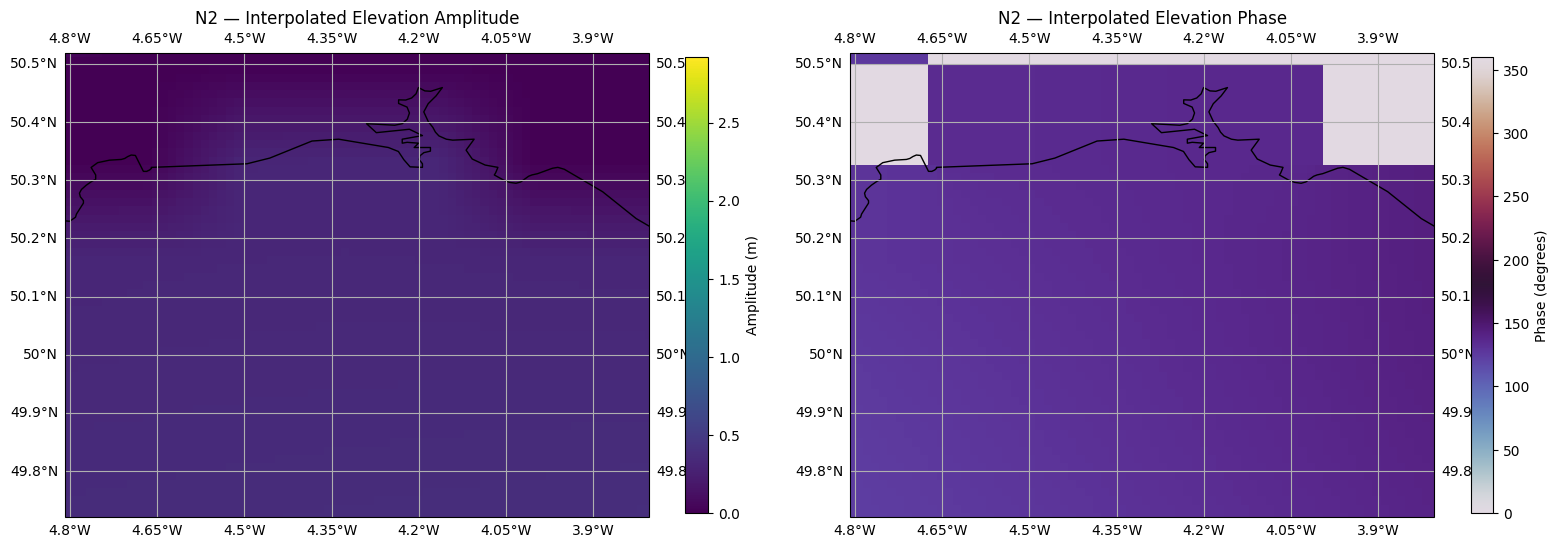

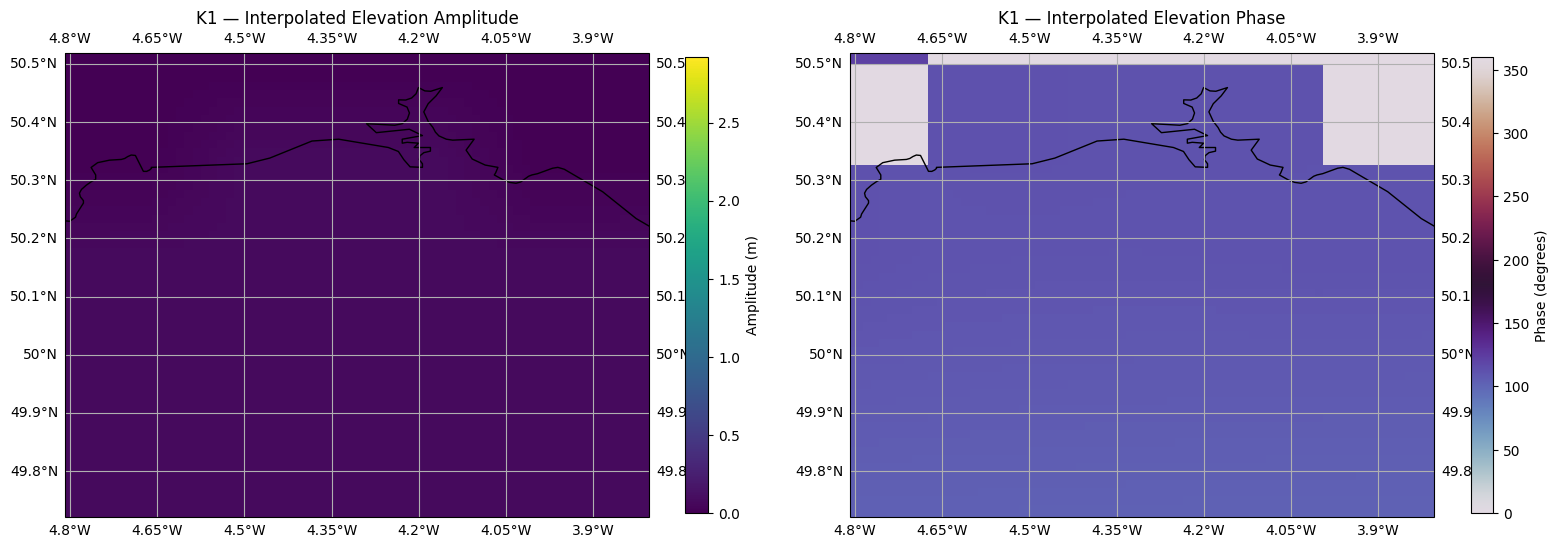

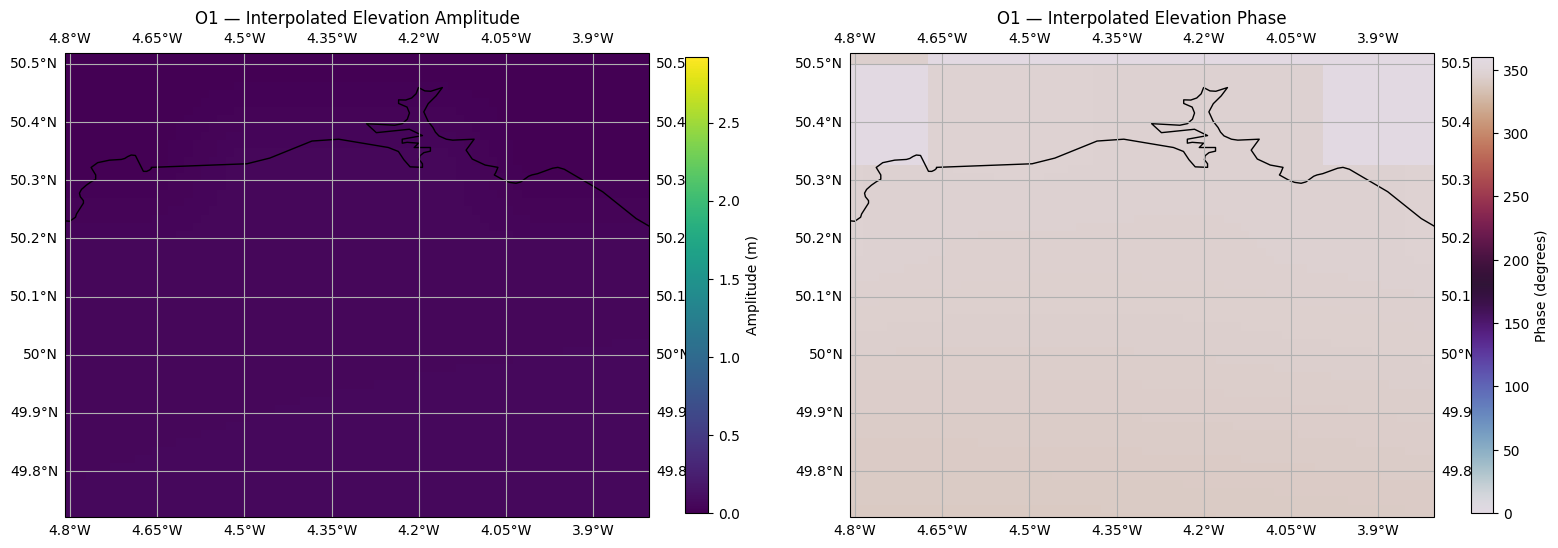

In [6]:
n_lon, n_lat = lon_2D.shape

for c_idx, constituent in enumerate(h_result.constituents):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6),
                             subplot_kw={'projection': ccrs.PlateCarree()})

    # Reshape flat interpolated data back to 2D grid
    amp_2d = h_result.amplitudes[:, c_idx].reshape(n_lon, n_lat)
    phase_2d = h_result.phases[:, c_idx].reshape(n_lon, n_lat)

    # Amplitude
    pc = axes[0].pcolormesh(lon_2D, lat_2D, amp_2d, cmap='viridis',
                            transform=ccrs.PlateCarree(), shading='auto',
                            vmin=h_amp_vmin, vmax=h_amp_vmax)
    axes[0].coastlines(resolution='10m')
    axes[0].add_feature(cfeature.LAND, facecolor='lightgrey')
    axes[0].gridlines(draw_labels=True)
    axes[0].set_extent(extent, crs=ccrs.PlateCarree())
    cbar = plt.colorbar(pc, ax=axes[0], shrink=0.8)
    cbar.set_label('Amplitude (m)')
    axes[0].set_title(f'{constituent} — Interpolated Elevation Amplitude')

    # Phase
    pc = axes[1].pcolormesh(lon_2D, lat_2D, phase_2d, cmap='twilight',
                            transform=ccrs.PlateCarree(), shading='auto',
                            vmin=0, vmax=360)
    axes[1].coastlines(resolution='10m')
    axes[1].add_feature(cfeature.LAND, facecolor='lightgrey')
    axes[1].gridlines(draw_labels=True)
    axes[1].set_extent(extent, crs=ccrs.PlateCarree())
    cbar = plt.colorbar(pc, ax=axes[1], shrink=0.8)
    cbar.set_label('Phase (degrees)')
    axes[1].set_title(f'{constituent} — Interpolated Elevation Phase')

    plt.tight_layout()
    plt.show()

## Step 6: Read and Interpolate Velocity Harmonics (u and v)

The TPXO velocity file contains both u (west-east) and v (south-north) components, each
on their own grid (`lon_u`/`lat_u` and `lon_v`/`lat_v`). We read and interpolate them
separately.

Note: TPXO9 velocity amplitudes are in cm/s.

In [7]:
# Path to the TPXO9 velocity harmonics file
tpxo_u_file = pathlib.Path('/data/sthenno1/backup/jcl/data/TPXO/DATA/u_tpxo9.v1.nc')

# Read u-component harmonics
u_reader = TPXOHarmonicsReader(str(tpxo_u_file))
u_var_names = get_tpxo_harmonics_names('u')
u_harmonics = u_reader.read_harmonics(constituents, u_var_names)

# Read v-component harmonics
v_reader = TPXOHarmonicsReader(str(tpxo_u_file))
v_var_names = get_tpxo_harmonics_names('v')
v_harmonics = v_reader.read_harmonics(constituents, v_var_names)

print(f'u amplitude shape: {np.asarray(u_harmonics.amplitudes).shape}')
print(f'v amplitude shape: {np.asarray(v_harmonics.amplitudes).shape}')

# Interpolate both components onto the target grid
u_interpolator = TPXOInterpolator(u_harmonics)
u_result = u_interpolator.interpolate(interp_coords)

v_interpolator = TPXOInterpolator(v_harmonics)
v_result = v_interpolator.interpolate(interp_coords)

print(f'Interpolated u amplitude shape: {u_result.amplitudes.shape}')
print(f'Interpolated v amplitude shape: {v_result.amplitudes.shape}')

u amplitude shape: (5, 2160, 1081)
v amplitude shape: (5, 2160, 1081)
Interpolated u amplitude shape: (4104, 5)
Interpolated v amplitude shape: (4104, 5)


## Step 7a: Plot Original (Uninterpolated) Velocity Data

The raw TPXO velocity harmonics for u and v, subset to the same domain.

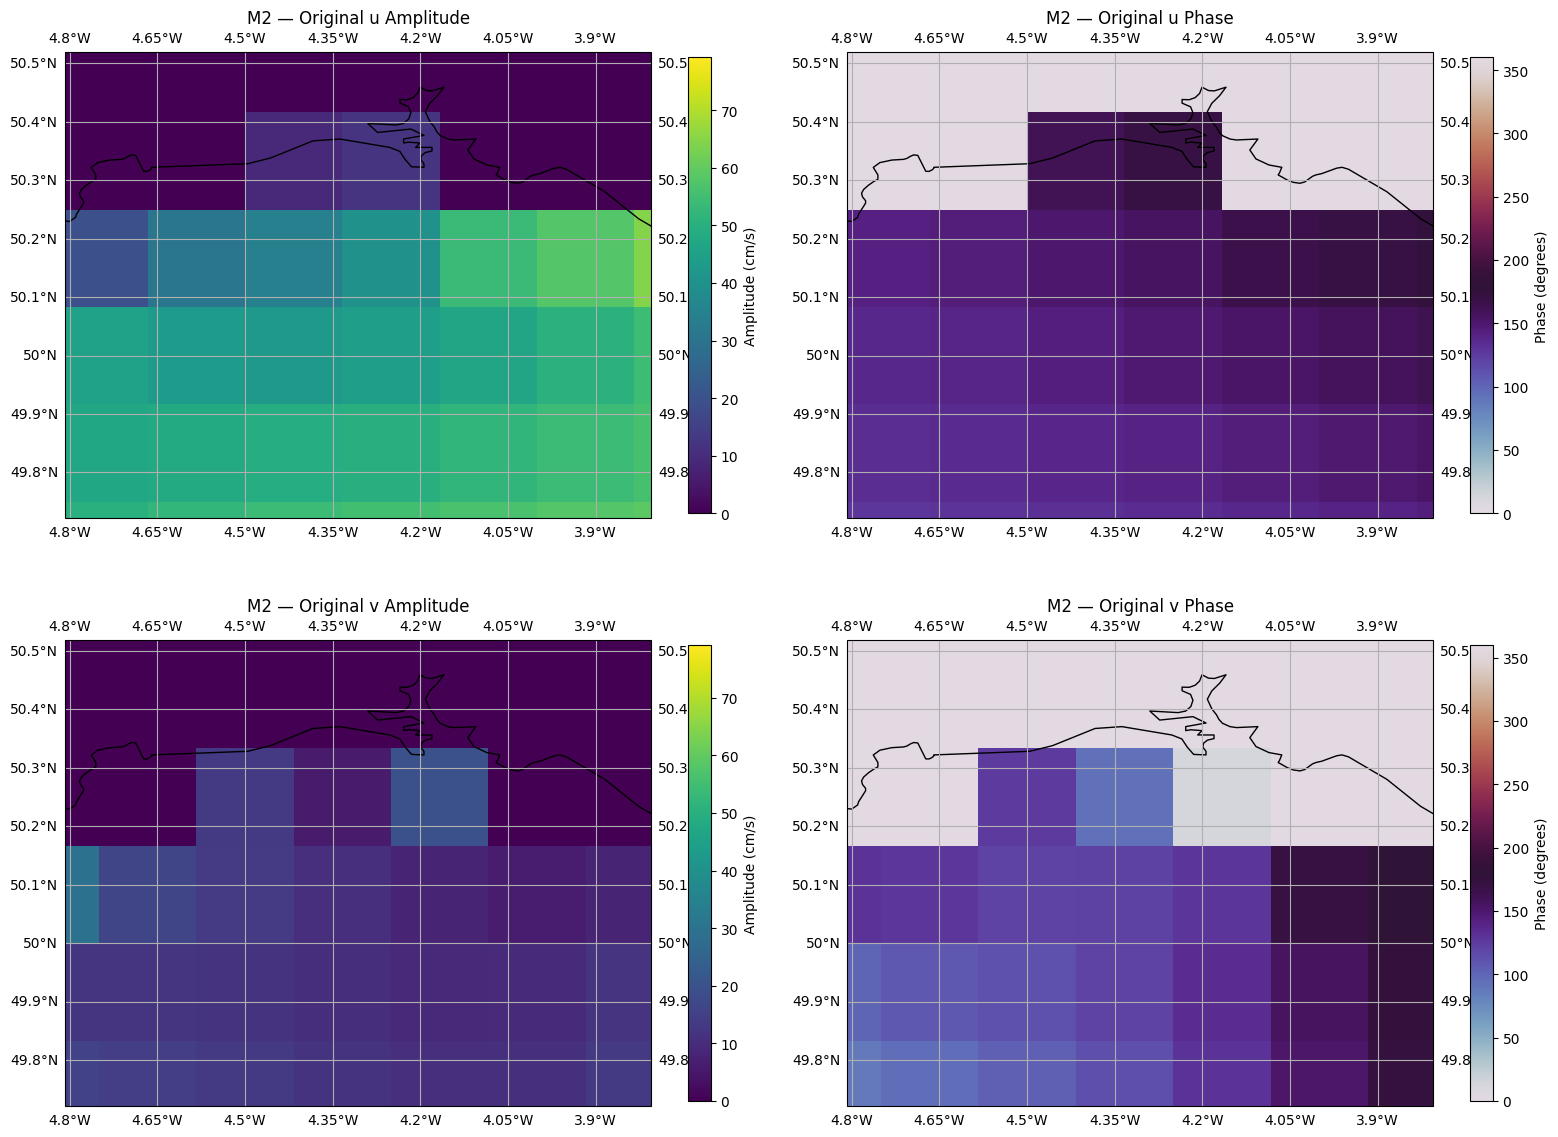

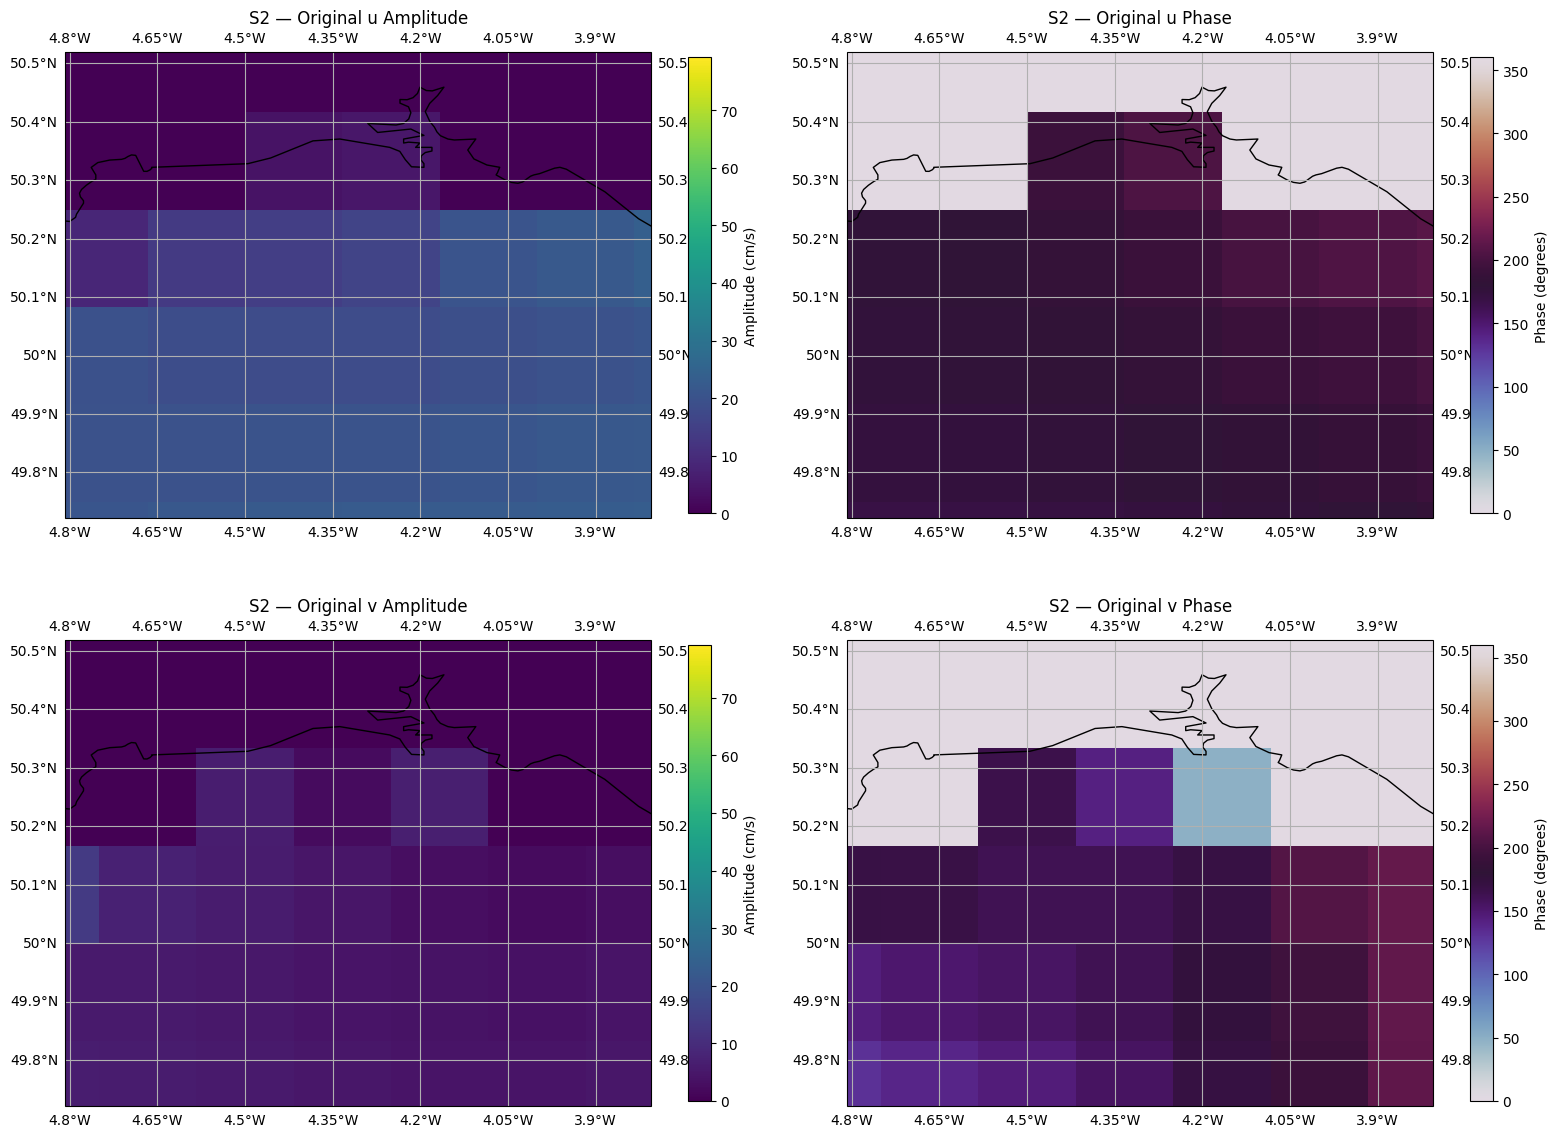

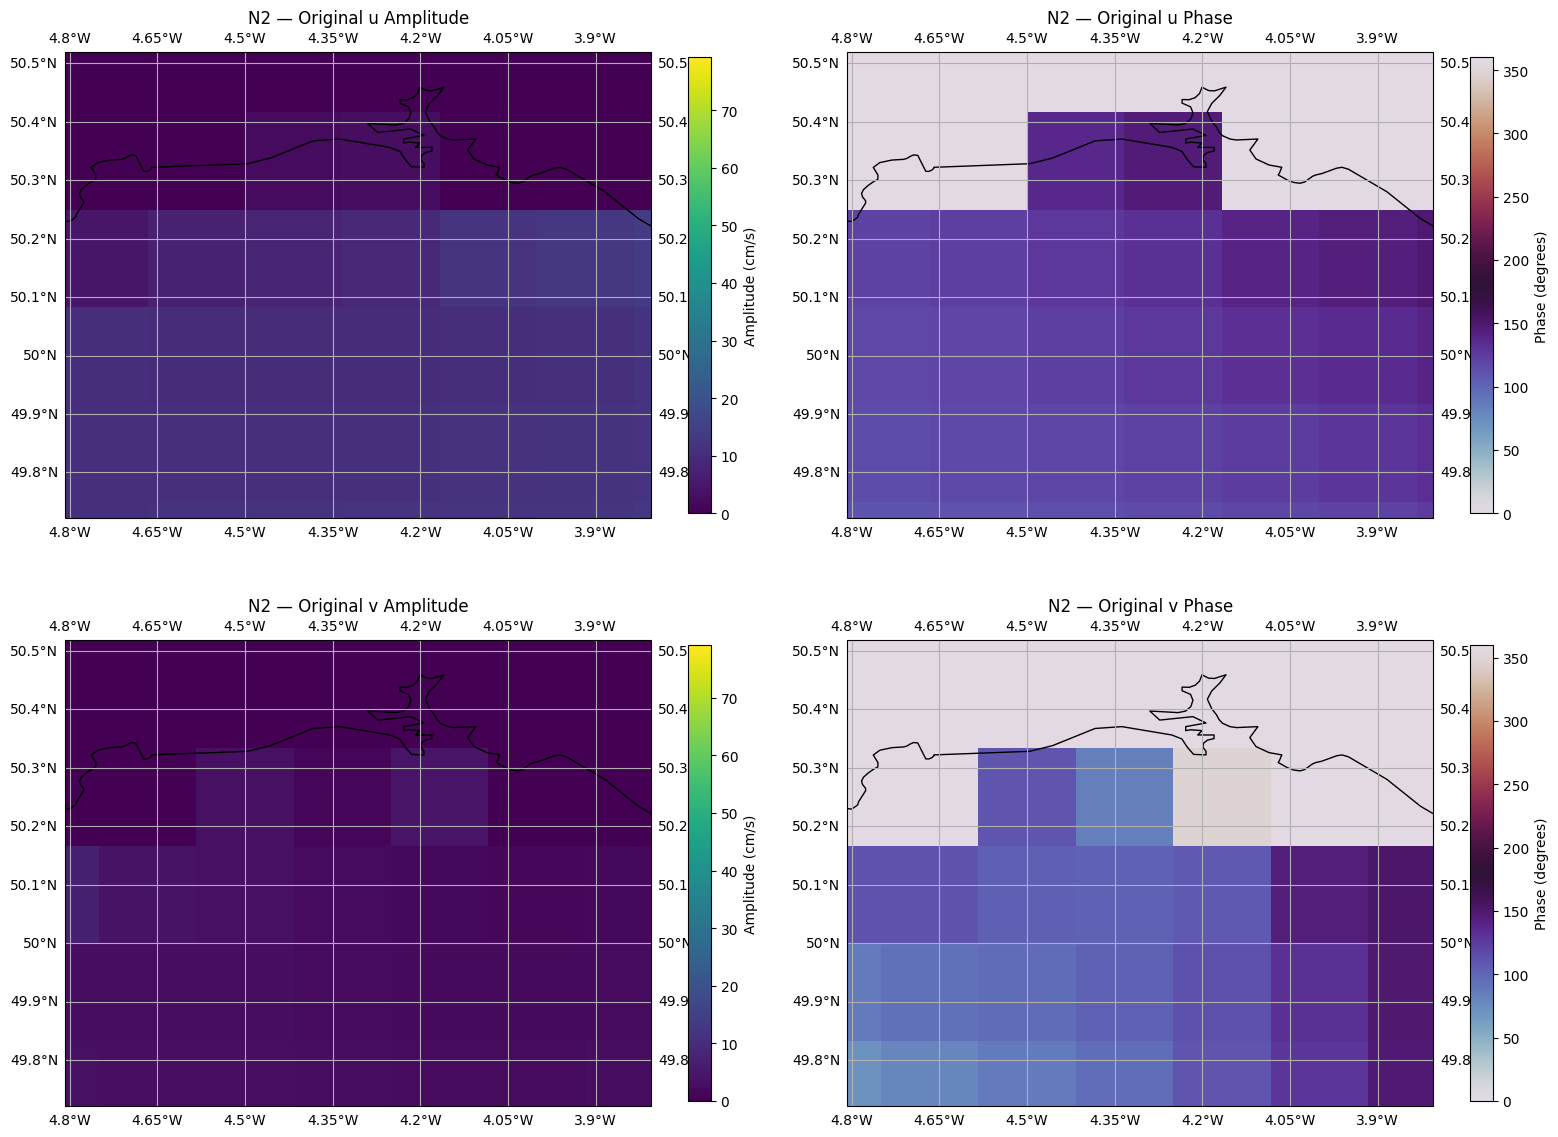

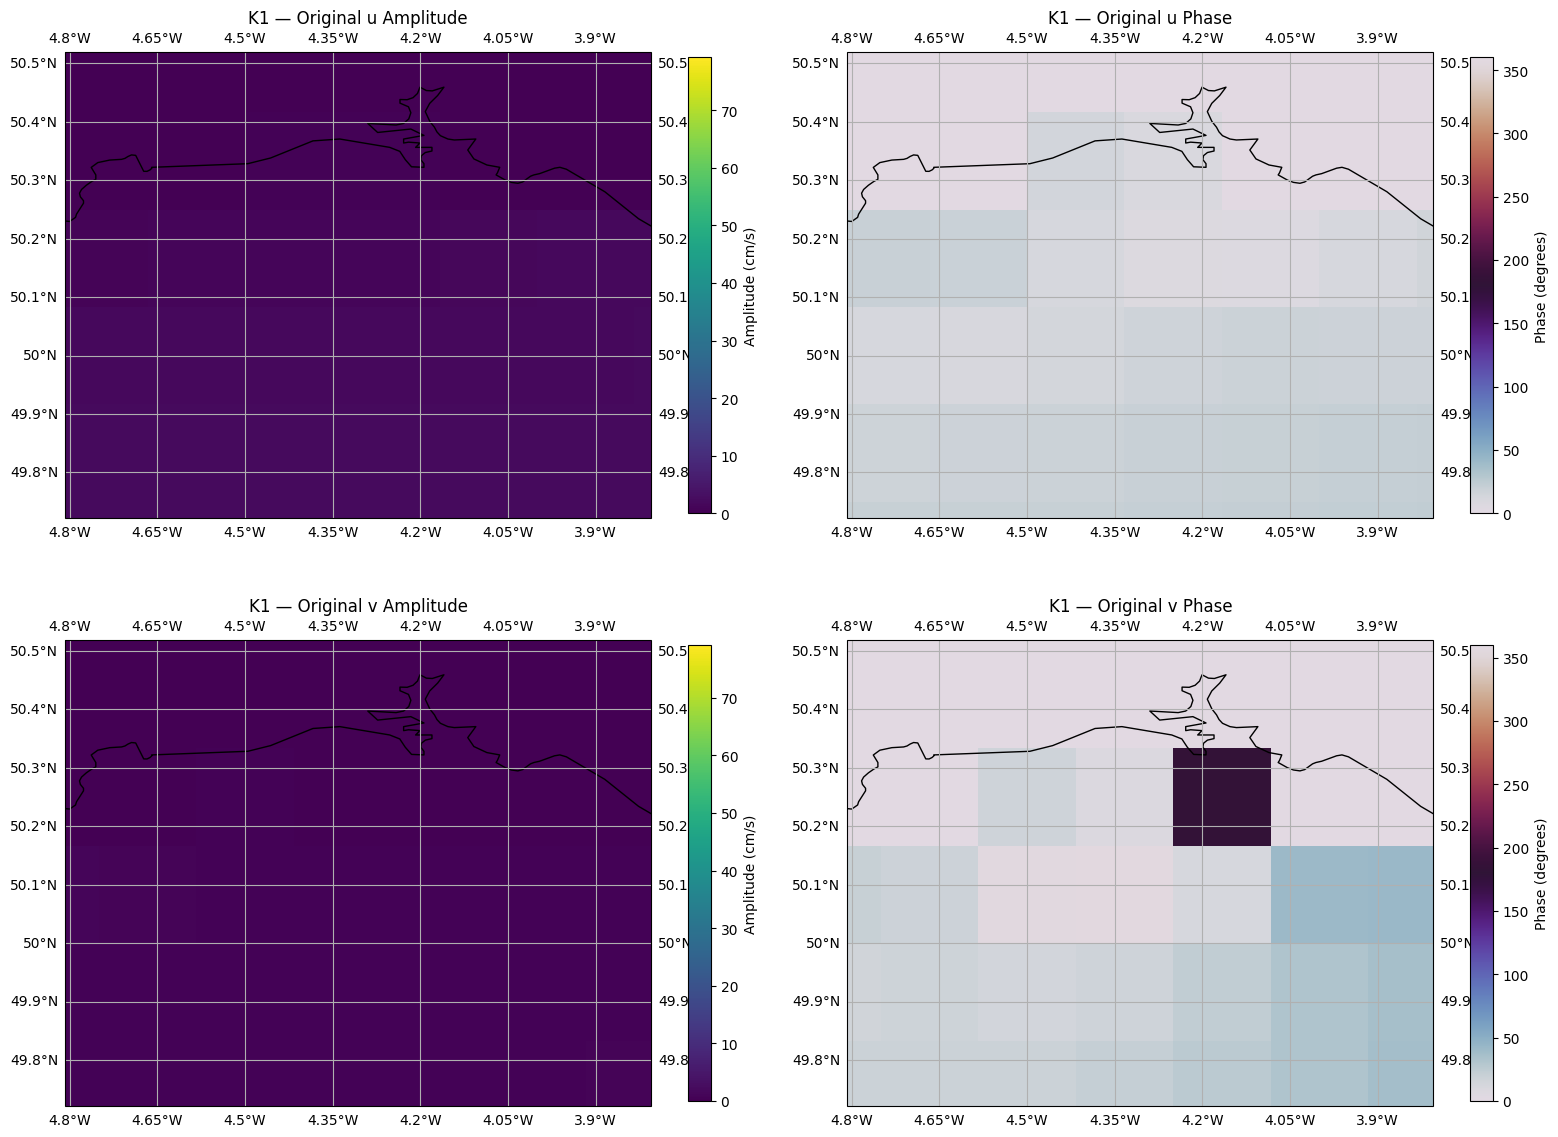

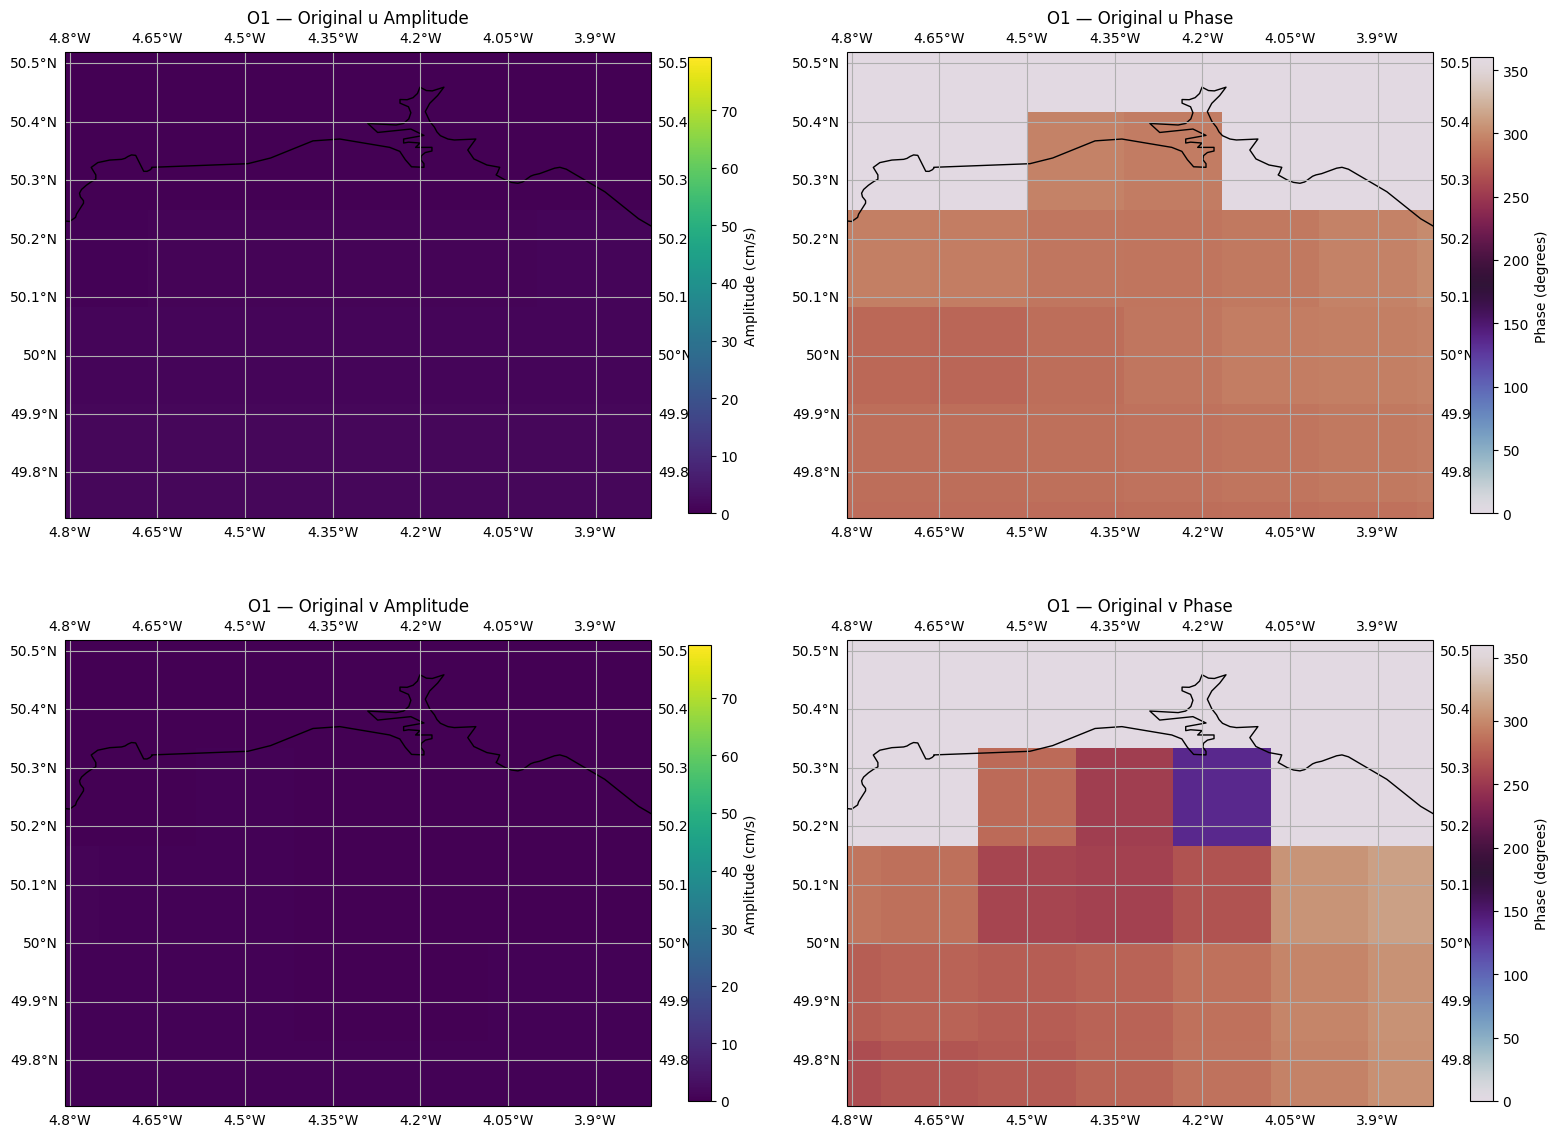

In [8]:
# Prepare the raw TPXO velocity grids for plotting
def subset_tpxo_raw(harmonics):
    """Shift longitudes and subset raw TPXO harmonics to the domain."""
    lon_1d = np.unique(np.asarray(harmonics.longitude))
    lat_1d = np.unique(np.asarray(harmonics.latitude))
    lon_1d = np.where(lon_1d > 180, lon_1d - 360, lon_1d)
    sort_idx = np.argsort(lon_1d)
    lon_1d = lon_1d[sort_idx]

    margin = 0.5
    lon_mask = (lon_1d >= grid_lims.lon_min - margin) & (lon_1d <= grid_lims.lon_max + margin)
    lat_mask = (lat_1d >= grid_lims.lat_min - margin) & (lat_1d <= grid_lims.lat_max + margin)

    lon_sub = lon_1d[lon_mask]
    lat_sub = lat_1d[lat_mask]
    lon_2d, lat_2d = np.meshgrid(lon_sub, lat_sub, indexing='ij')

    amp = np.asarray(harmonics.amplitudes)[:, sort_idx, :][:, lon_mask, :][:, :, lat_mask]
    phase = np.asarray(harmonics.phases)[:, sort_idx, :][:, lon_mask, :][:, :, lat_mask]
    return lon_2d, lat_2d, amp, phase


u_lon_sub, u_lat_sub, u_amp_sub, u_phase_sub = subset_tpxo_raw(u_harmonics)
v_lon_sub, v_lat_sub, v_amp_sub, v_phase_sub = subset_tpxo_raw(v_harmonics)

# Compute shared colorbar limits across all constituents for original and interpolated
vel_amp_vmin = min(np.nanmin(u_amp_sub), np.nanmin(v_amp_sub),
                   np.nanmin(u_result.amplitudes), np.nanmin(v_result.amplitudes))
vel_amp_vmax = max(np.nanmax(u_amp_sub), np.nanmax(v_amp_sub),
                   np.nanmax(u_result.amplitudes), np.nanmax(v_result.amplitudes))

for c_idx, constituent in enumerate(constituents):
    fig, axes = plt.subplots(2, 2, figsize=(16, 12),
                             subplot_kw={'projection': ccrs.PlateCarree()})

    # u amplitude
    pc = axes[0, 0].pcolormesh(u_lon_sub, u_lat_sub, u_amp_sub[c_idx],
                               cmap='viridis', transform=ccrs.PlateCarree(), shading='auto',
                               vmin=vel_amp_vmin, vmax=vel_amp_vmax)
    axes[0, 0].coastlines(resolution='10m')
    axes[0, 0].add_feature(cfeature.LAND, facecolor='lightgrey')
    axes[0, 0].gridlines(draw_labels=True)
    axes[0, 0].set_extent(extent, crs=ccrs.PlateCarree())
    cbar = plt.colorbar(pc, ax=axes[0, 0], shrink=0.8)
    cbar.set_label('Amplitude (cm/s)')
    axes[0, 0].set_title(f'{constituent} — Original u Amplitude')

    # u phase
    pc = axes[0, 1].pcolormesh(u_lon_sub, u_lat_sub, u_phase_sub[c_idx],
                               cmap='twilight', transform=ccrs.PlateCarree(), shading='auto',
                               vmin=0, vmax=360)
    axes[0, 1].coastlines(resolution='10m')
    axes[0, 1].add_feature(cfeature.LAND, facecolor='lightgrey')
    axes[0, 1].gridlines(draw_labels=True)
    axes[0, 1].set_extent(extent, crs=ccrs.PlateCarree())
    cbar = plt.colorbar(pc, ax=axes[0, 1], shrink=0.8)
    cbar.set_label('Phase (degrees)')
    axes[0, 1].set_title(f'{constituent} — Original u Phase')

    # v amplitude
    pc = axes[1, 0].pcolormesh(v_lon_sub, v_lat_sub, v_amp_sub[c_idx],
                               cmap='viridis', transform=ccrs.PlateCarree(), shading='auto',
                               vmin=vel_amp_vmin, vmax=vel_amp_vmax)
    axes[1, 0].coastlines(resolution='10m')
    axes[1, 0].add_feature(cfeature.LAND, facecolor='lightgrey')
    axes[1, 0].gridlines(draw_labels=True)
    axes[1, 0].set_extent(extent, crs=ccrs.PlateCarree())
    cbar = plt.colorbar(pc, ax=axes[1, 0], shrink=0.8)
    cbar.set_label('Amplitude (cm/s)')
    axes[1, 0].set_title(f'{constituent} — Original v Amplitude')

    # v phase
    pc = axes[1, 1].pcolormesh(v_lon_sub, v_lat_sub, v_phase_sub[c_idx],
                               cmap='twilight', transform=ccrs.PlateCarree(), shading='auto',
                               vmin=0, vmax=360)
    axes[1, 1].coastlines(resolution='10m')
    axes[1, 1].add_feature(cfeature.LAND, facecolor='lightgrey')
    axes[1, 1].gridlines(draw_labels=True)
    axes[1, 1].set_extent(extent, crs=ccrs.PlateCarree())
    cbar = plt.colorbar(pc, ax=axes[1, 1], shrink=0.8)
    cbar.set_label('Phase (degrees)')
    axes[1, 1].set_title(f'{constituent} — Original v Phase')

    plt.tight_layout()
    plt.show()

## Step 7b: Plot Interpolated Velocity Amplitude and Phase

Plot the interpolated u and v velocity amplitudes and phases for each constituent.

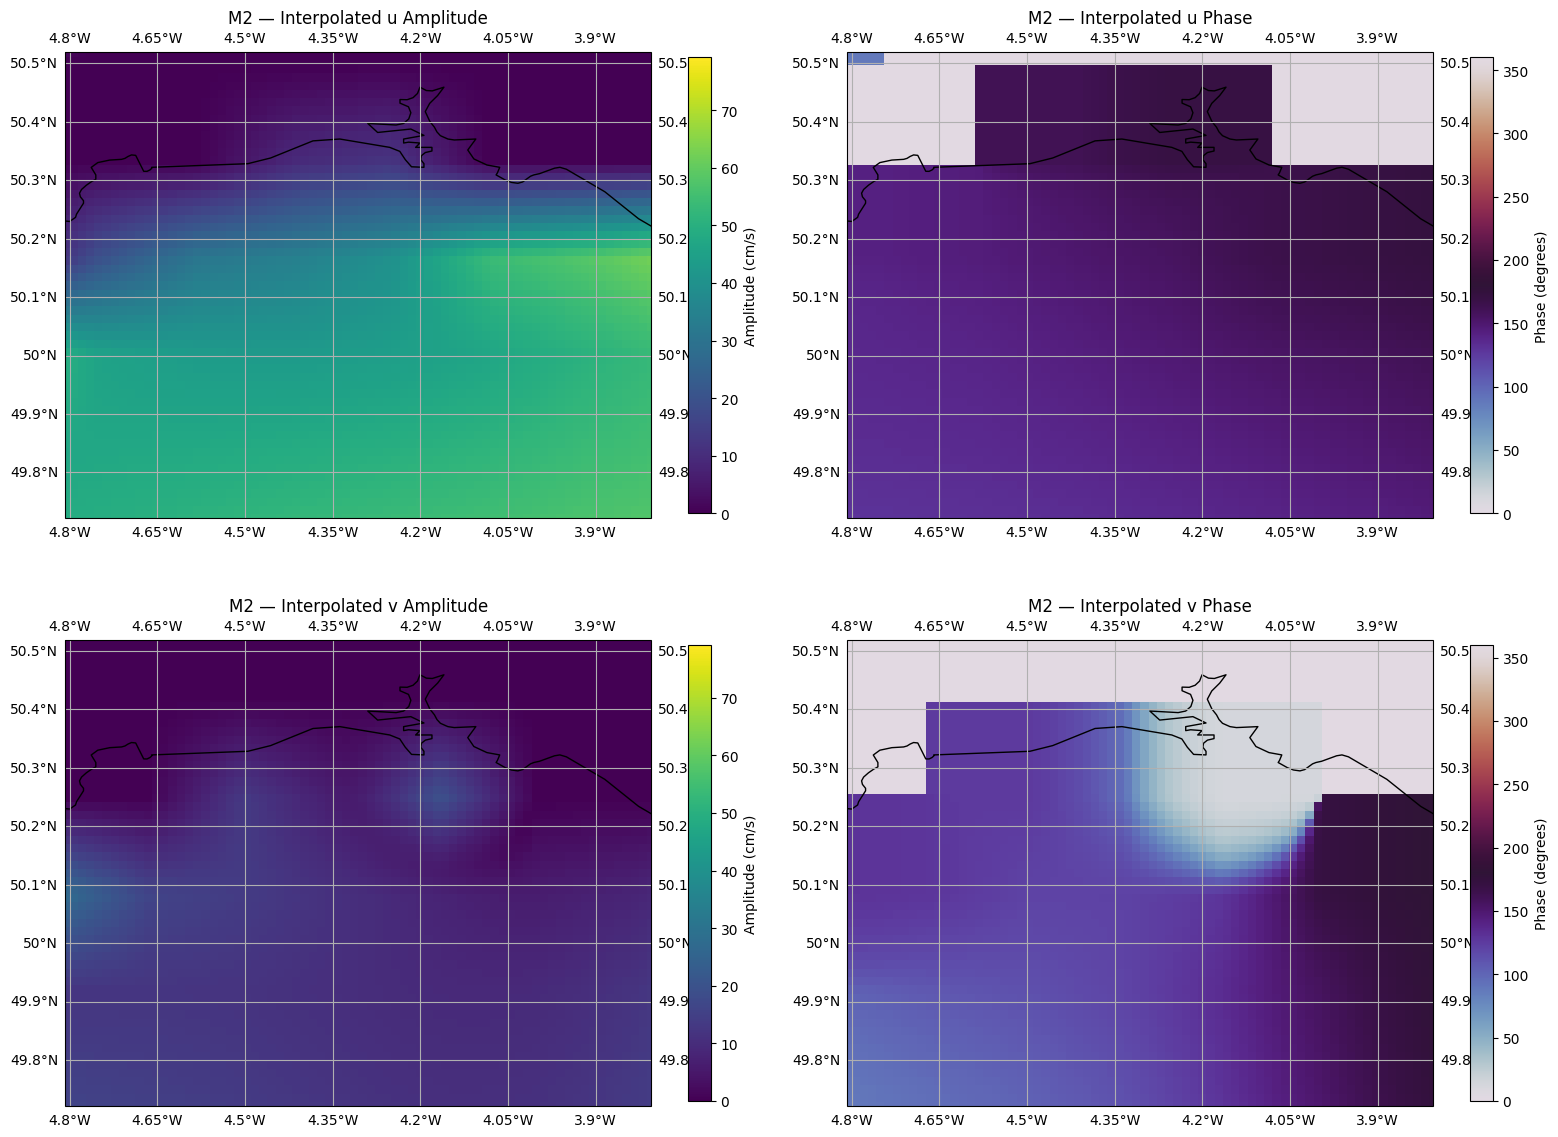

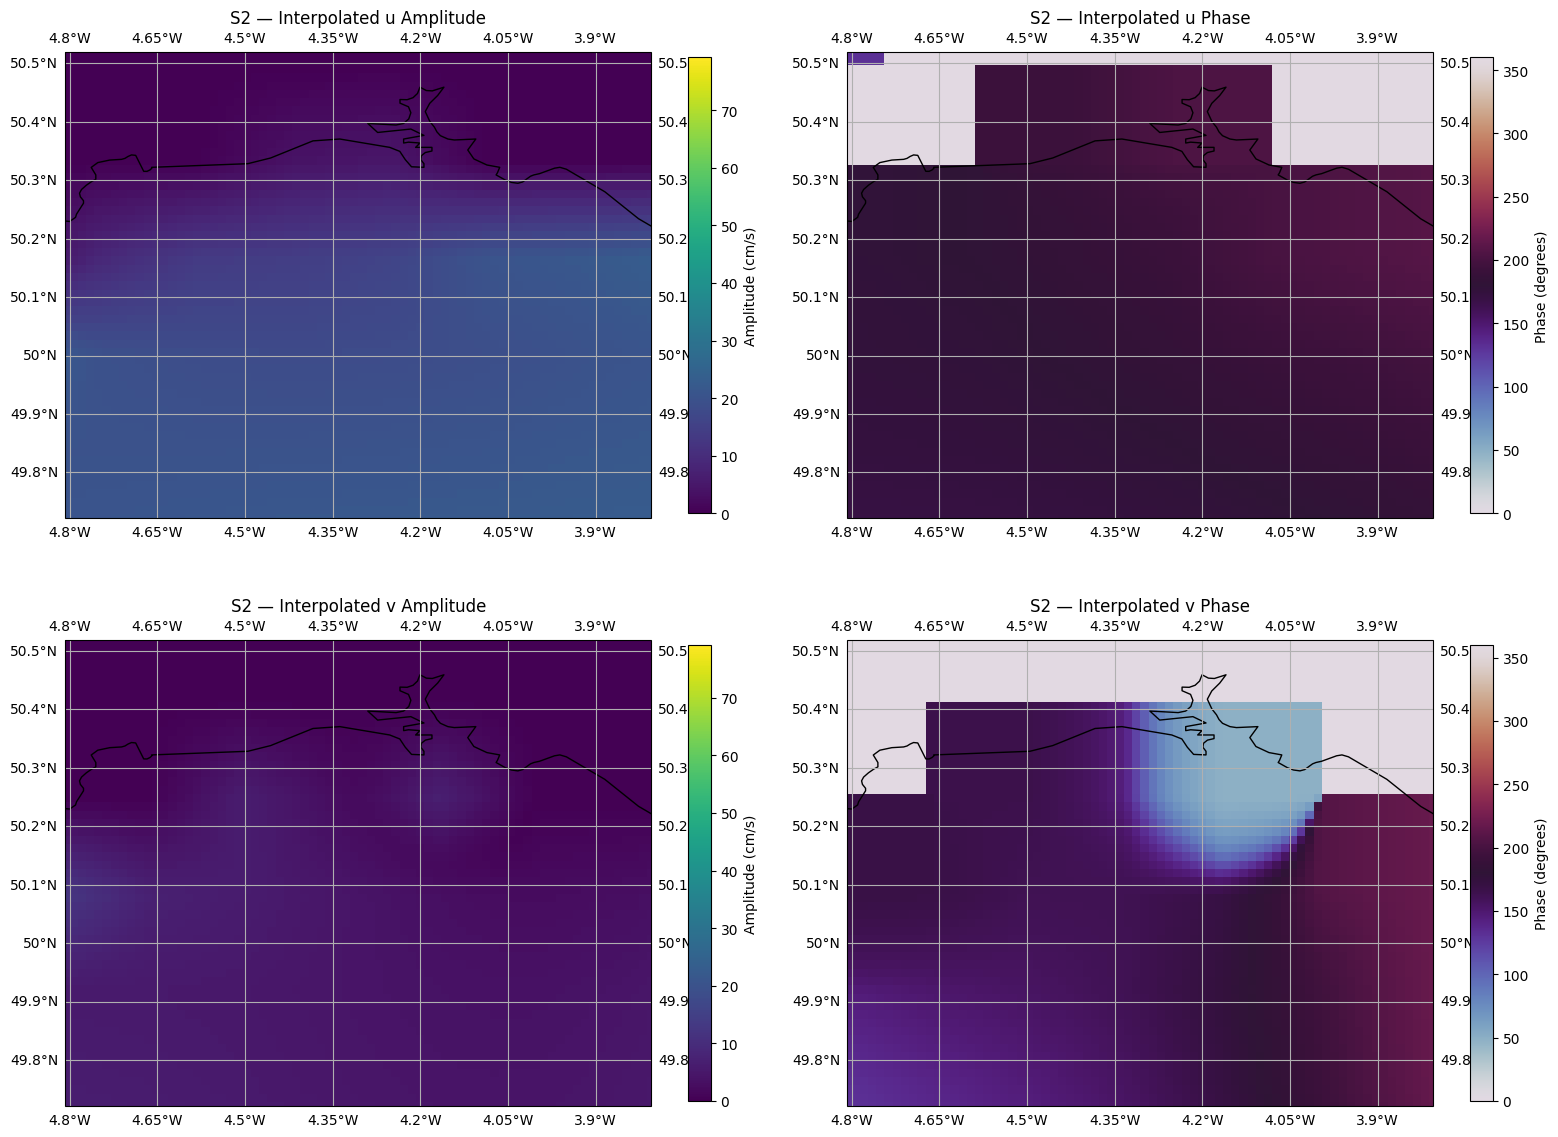

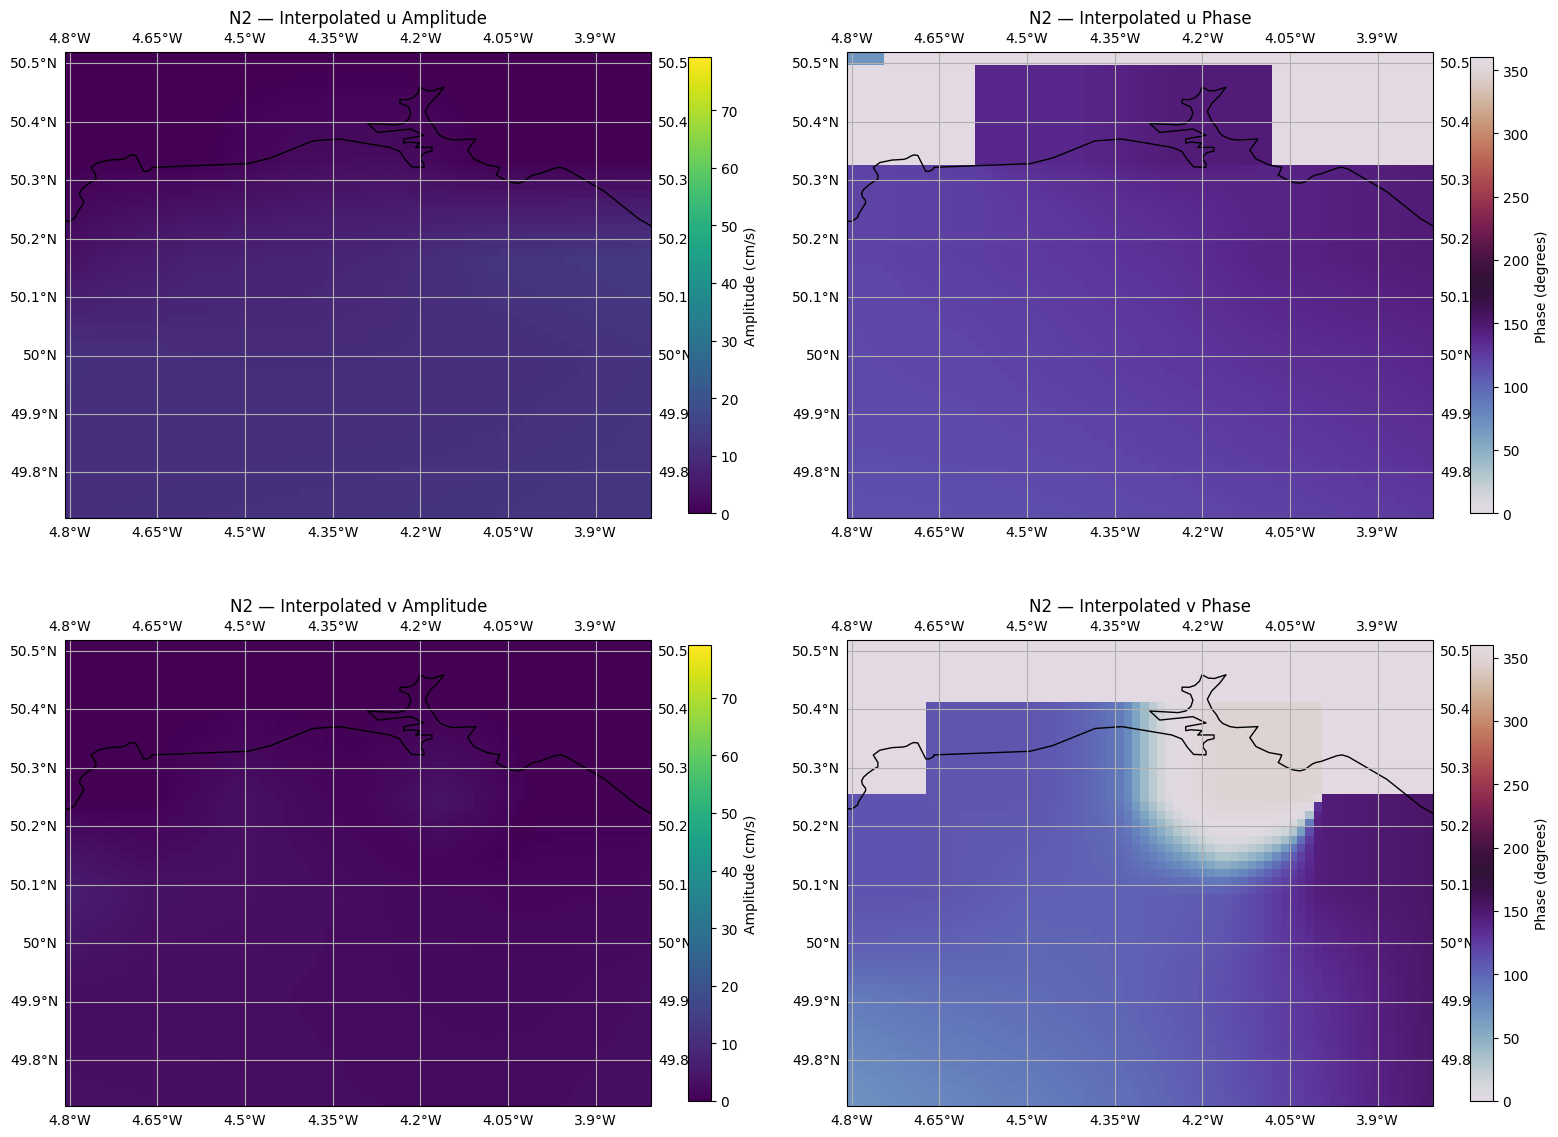

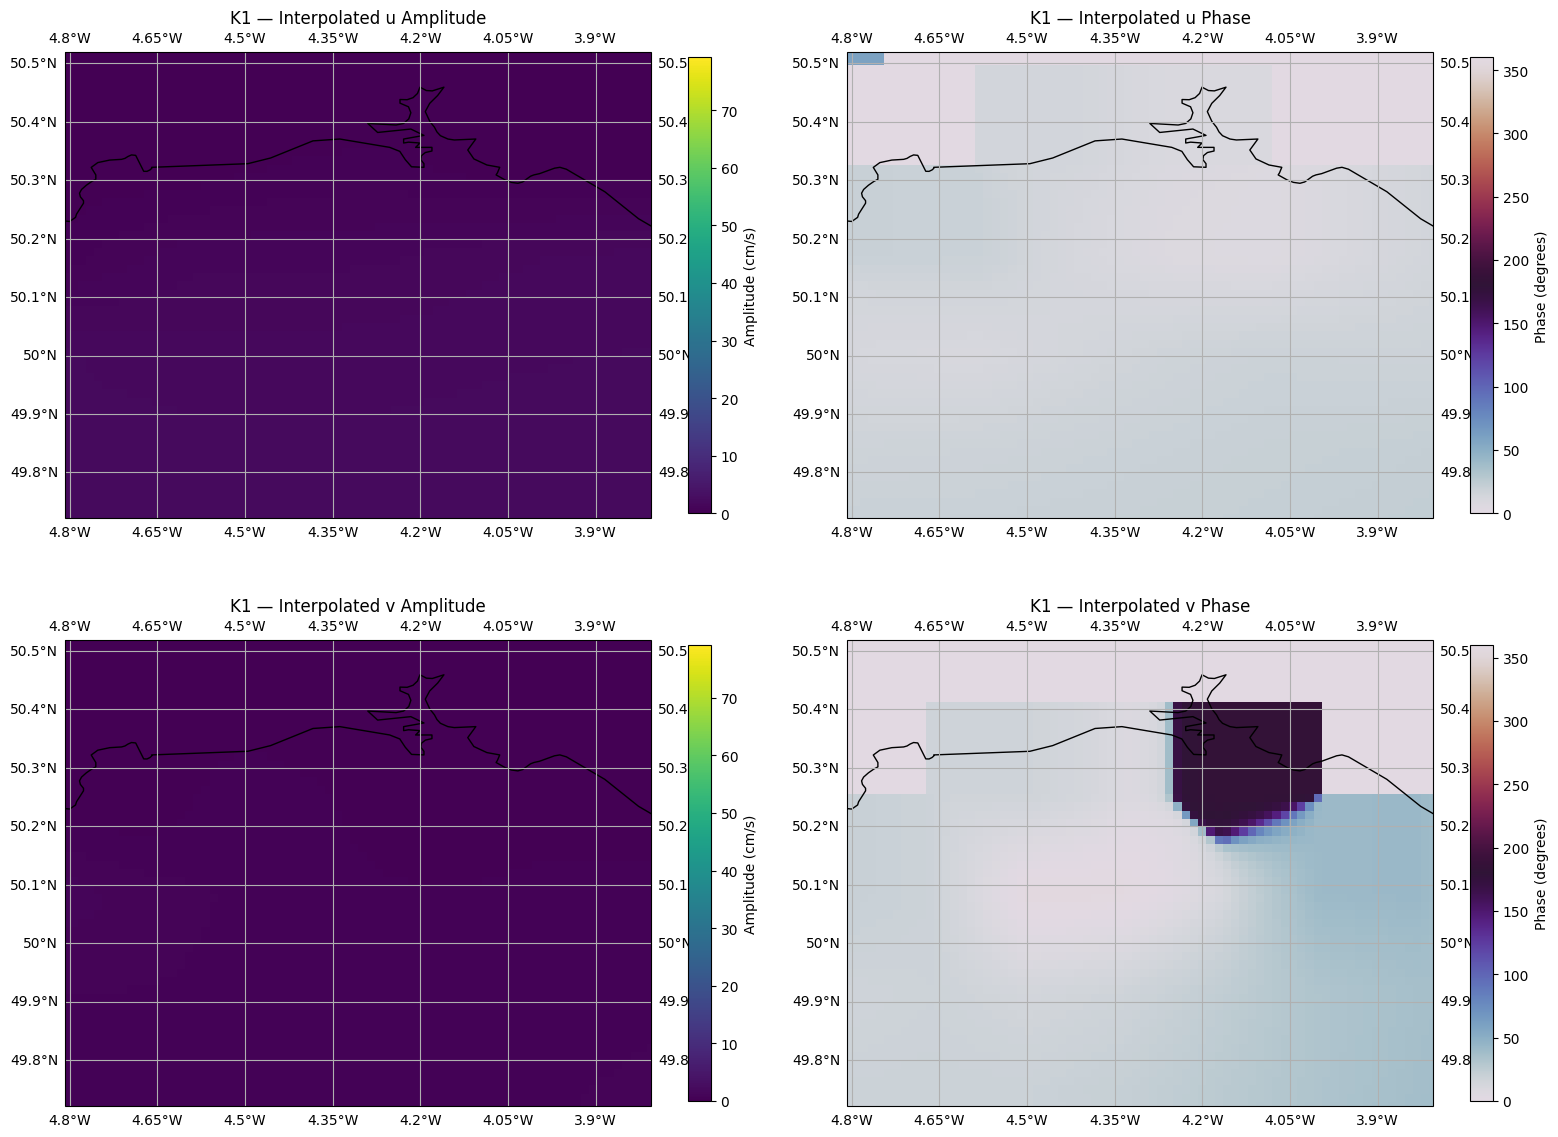

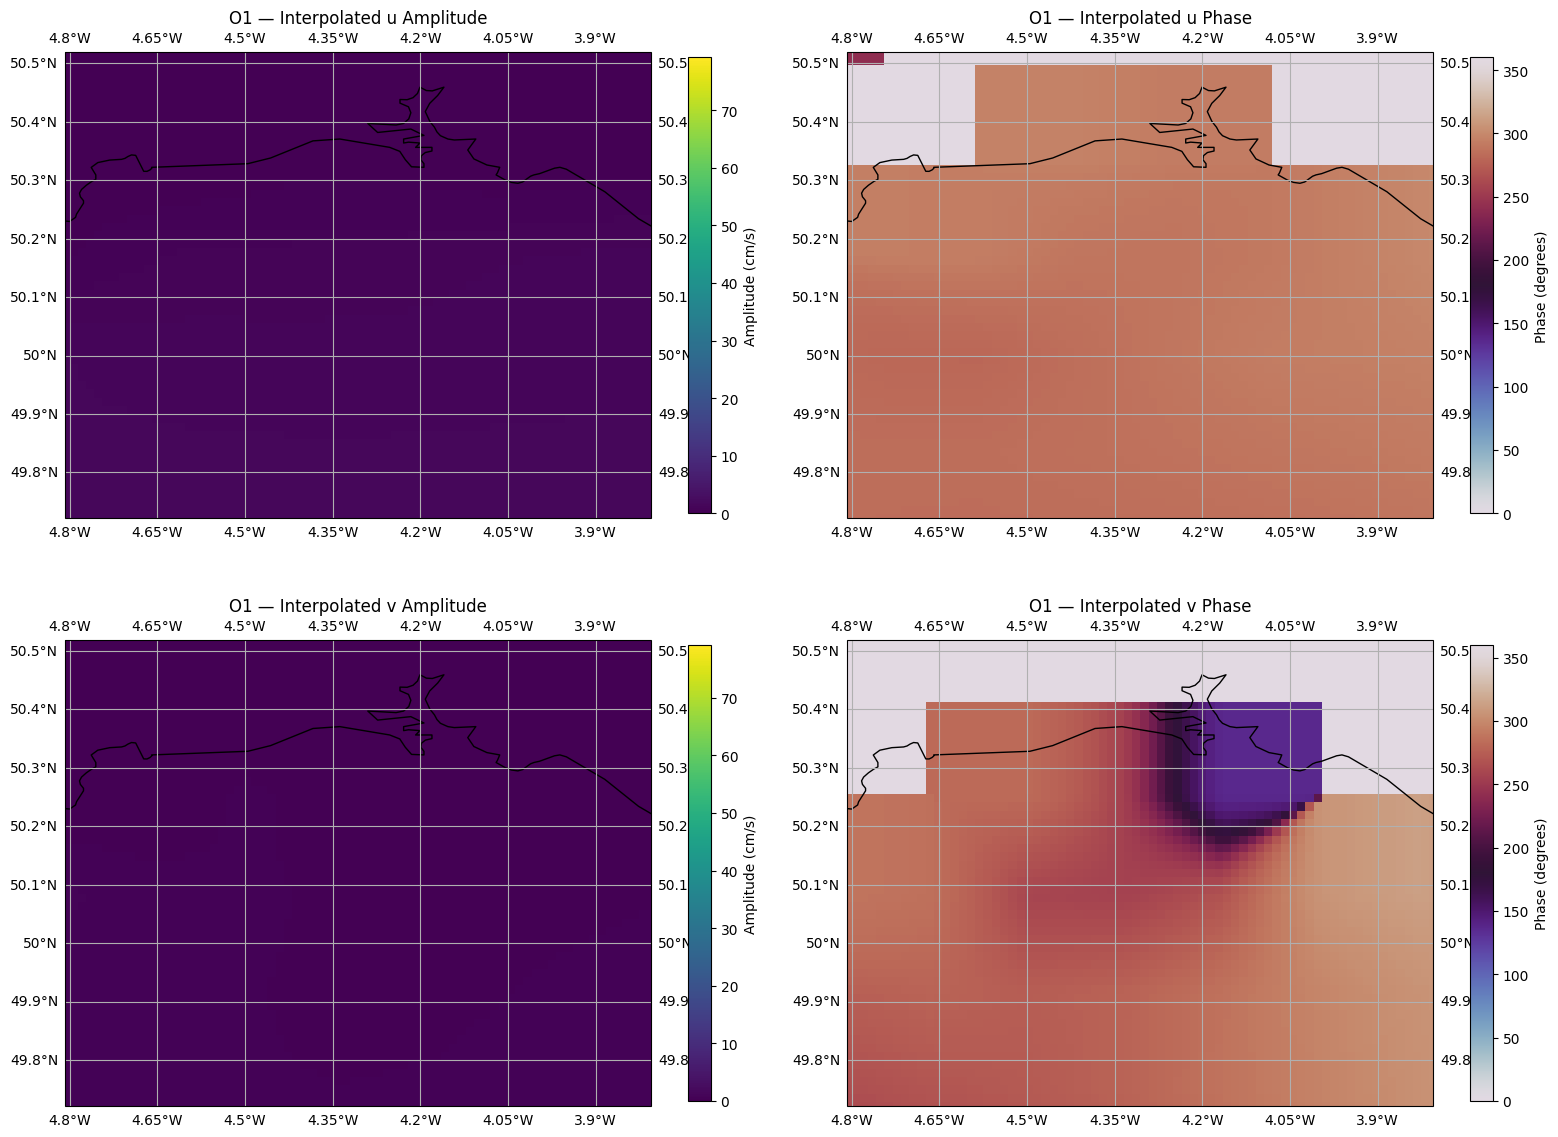

In [9]:
for c_idx, constituent in enumerate(constituents):
    fig, axes = plt.subplots(2, 2, figsize=(16, 12),
                             subplot_kw={'projection': ccrs.PlateCarree()})

    # Reshape flat interpolated data back to 2D grid
    u_amp_2d = u_result.amplitudes[:, c_idx].reshape(n_lon, n_lat)
    u_phase_2d = u_result.phases[:, c_idx].reshape(n_lon, n_lat)
    v_amp_2d = v_result.amplitudes[:, c_idx].reshape(n_lon, n_lat)
    v_phase_2d = v_result.phases[:, c_idx].reshape(n_lon, n_lat)

    # u amplitude
    pc = axes[0, 0].pcolormesh(lon_2D, lat_2D, u_amp_2d, cmap='viridis',
                               transform=ccrs.PlateCarree(), shading='auto',
                               vmin=vel_amp_vmin, vmax=vel_amp_vmax)
    axes[0, 0].coastlines(resolution='10m')
    axes[0, 0].add_feature(cfeature.LAND, facecolor='lightgrey')
    axes[0, 0].gridlines(draw_labels=True)
    axes[0, 0].set_extent(extent, crs=ccrs.PlateCarree())
    cbar = plt.colorbar(pc, ax=axes[0, 0], shrink=0.8)
    cbar.set_label('Amplitude (cm/s)')
    axes[0, 0].set_title(f'{constituent} — Interpolated u Amplitude')

    # u phase
    pc = axes[0, 1].pcolormesh(lon_2D, lat_2D, u_phase_2d, cmap='twilight',
                               transform=ccrs.PlateCarree(), shading='auto',
                               vmin=0, vmax=360)
    axes[0, 1].coastlines(resolution='10m')
    axes[0, 1].add_feature(cfeature.LAND, facecolor='lightgrey')
    axes[0, 1].gridlines(draw_labels=True)
    axes[0, 1].set_extent(extent, crs=ccrs.PlateCarree())
    cbar = plt.colorbar(pc, ax=axes[0, 1], shrink=0.8)
    cbar.set_label('Phase (degrees)')
    axes[0, 1].set_title(f'{constituent} — Interpolated u Phase')

    # v amplitude
    pc = axes[1, 0].pcolormesh(lon_2D, lat_2D, v_amp_2d, cmap='viridis',
                               transform=ccrs.PlateCarree(), shading='auto',
                               vmin=vel_amp_vmin, vmax=vel_amp_vmax)
    axes[1, 0].coastlines(resolution='10m')
    axes[1, 0].add_feature(cfeature.LAND, facecolor='lightgrey')
    axes[1, 0].gridlines(draw_labels=True)
    axes[1, 0].set_extent(extent, crs=ccrs.PlateCarree())
    cbar = plt.colorbar(pc, ax=axes[1, 0], shrink=0.8)
    cbar.set_label('Amplitude (cm/s)')
    axes[1, 0].set_title(f'{constituent} — Interpolated v Amplitude')

    # v phase
    pc = axes[1, 1].pcolormesh(lon_2D, lat_2D, v_phase_2d, cmap='twilight',
                               transform=ccrs.PlateCarree(), shading='auto',
                               vmin=0, vmax=360)
    axes[1, 1].coastlines(resolution='10m')
    axes[1, 1].add_feature(cfeature.LAND, facecolor='lightgrey')
    axes[1, 1].gridlines(draw_labels=True)
    axes[1, 1].set_extent(extent, crs=ccrs.PlateCarree())
    cbar = plt.colorbar(pc, ax=axes[1, 1], shrink=0.8)
    cbar.set_label('Phase (degrees)')
    axes[1, 1].set_title(f'{constituent} — Interpolated v Phase')

    plt.tight_layout()
    plt.show()